In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Straight Waveguide

`straight_dbu_factory(kcl)` returns a cached cell function whose arguments are
all in **DBU** (database units). Convert µm values with `kcl.to_dbu()`.

In [2]:
import kfactory as kf
from kfactory.factories.straight import straight_dbu_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


pdk = kf.KCLayout("FACTORIES_STRAIGHT_DEMO", infos=LAYER)
L = LAYER()

## Build a few waveguides

Each call with the same arguments returns the *same* cell object — that's the
`@kcl.cell` cache at work.

short name: straight_W500_L10000_LWG_ENone
long  name: straight_W500_L20000_LWG_ENone
same object (same args)? True


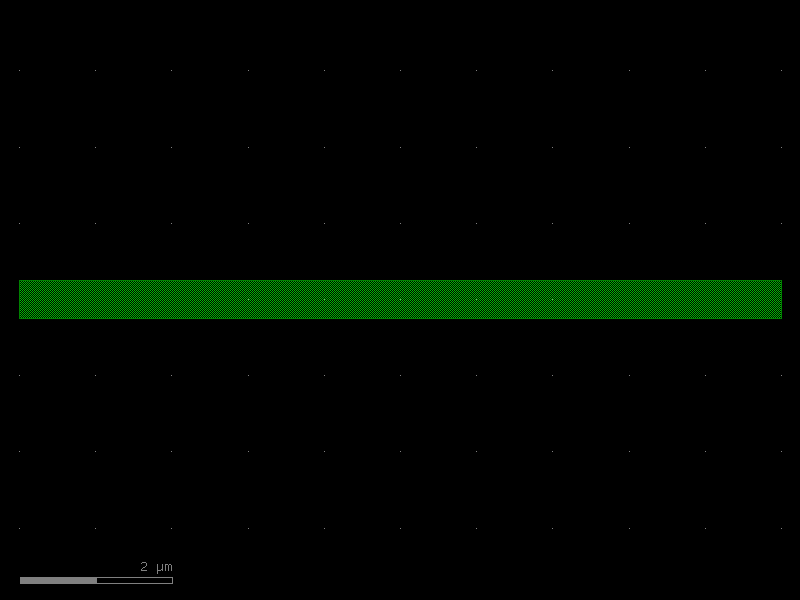

In [3]:
straight = straight_dbu_factory(pdk)

wg_short = straight(
    width=pdk.to_dbu(0.5),  # 500 DBU = 0.5 µm
    length=pdk.to_dbu(10.0),  # 10000 DBU = 10 µm
    layer=L.WG,
)
wg_long = straight(
    width=pdk.to_dbu(0.5),
    length=pdk.to_dbu(20.0),
    layer=L.WG,
)

print("short name:", wg_short.name)
print("long  name:", wg_long.name)
print(
    "same object (same args)?",
    wg_short is straight(pdk.to_dbu(0.5), pdk.to_dbu(10.0), L.WG),
)
wg_short

## Enclosure (cladding / exclude)

Pass a `LayerEnclosure` to add slab or exclude layers automatically.

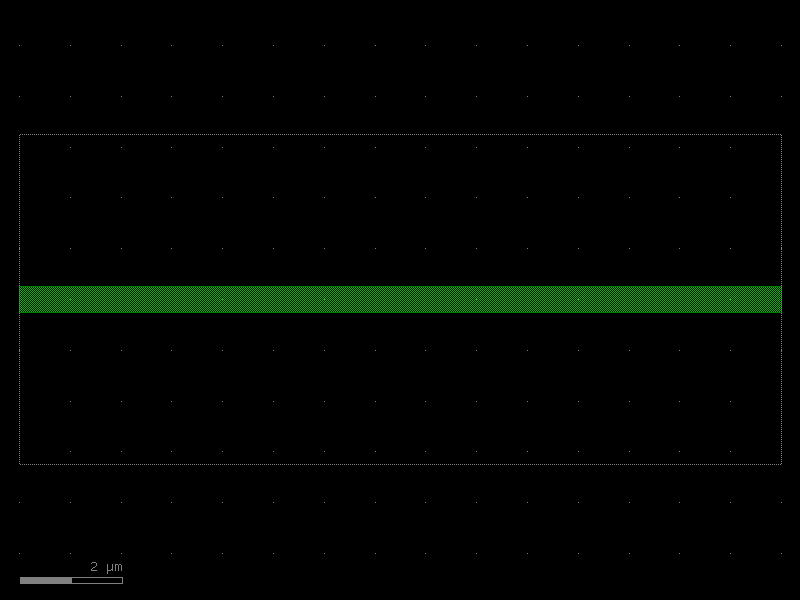

In [4]:
enc = kf.LayerEnclosure(
    sections=[(L.WGCLAD, pdk.to_dbu(3.0))],
    main_layer=L.WG,
    kcl=pdk,
)

wg_clad = straight(
    width=pdk.to_dbu(0.5),
    length=pdk.to_dbu(15.0),
    layer=L.WG,
    enclosure=enc,
)
wg_clad

## See Also

| Topic | Where |
|-------|-------|
| Cross-sections (alternative spec) | [Cross-Sections](../../cross_sections.py) |